# Correlating stock index performance with macroeconomic indicators using Regression

The target variables are: 
- Target (Y): daily change percentage 
- Predictors (X): Import, Export, inflation, interest rate, unemployment

Authors: Lohane da Cruz Evora and Irena Nguyen (NGUYEN THI HONG HAI)

## Install library

This project uses the following libraries:

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math
# For prediction
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
# note! [delete later!]: ModuleNotFoundError when importing the libraries --> view >> terminal >> pip install numpy pandas matplotlib seaborn scikit-learn kagglehub

## Dataset

### Introducing the dataset

This dataset contains information on global stock markets and macroeconomic indicators for 39 countries as of 2024-08-15. It covers countries across North America, Europe, Asia, including both developed (US, Japan, Germany, UK) and emerging economies (China, India, Brazil, etc.).

#### Key Features:
- Market Data: Country, stock index name, index value, daily change %.

- Economic Indicators: GDP growth rate, inflation, interest rates, unemployment.

- Others features: 
    - Financial Market Metrics: Market capitalization, bond yields, credit rating.
    - Commodities & Assets: Oil price, gold price, commodity index.
    - Risk & Stability: Political risk score, banking sector health, real estate index.
    - Trade & Growth: Export and import growth percentages.
- For the purpose of this project, only the features regarding the market as well as the economic indicators are included for the study.

In [3]:
# Importing dataset
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imaadmahmood/global-finance-and-economic-indicators-dataset-2024")

files = os.listdir(path)
print(files)

file_path = os.path.join(path, files[0])  # take first file
data = pd.read_csv(file_path)

data.head()

['Global finance data.csv']


,Country,Date,Stock_Index,Index_Value,Daily_Change_Percent,Market_Cap_Trillion_USD,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,...,Commodity_Index,Oil_Price_USD_Barrel,Gold_Price_USD_Ounce,Bond_Yield_10Y_Percent,Credit_Rating,Political_Risk_Score,Banking_Sector_Health,Real_Estate_Index,Export_Growth_Percent,Import_Growth_Percent
0,United States,2024-08-15,S&P_500,5437.2,0.34,51.2,2.8,2.9,5.50,3.7,...,1.12,77.85,2487.5,4.25,AAA,8.1,Strong,145.6,3.2,2.8
1,China,2024-08-15,Shanghai_Composite,2891.6,-0.82,12.4,5.2,0.8,3.10,5.2,...,0.98,77.85,2487.5,2.15,A+,6.7,Moderate,98.7,8.9,6.1
2,Japan,2024-08-15,Nikkei_225,36789.1,1.24,6.8,0.9,2.8,-0.10,2.4,...,1.05,77.85,2487.5,0.89,A+,8.4,Strong,89.3,5.1,4.7
3,Germany,2024-08-15,DAX,18234.5,0.67,2.9,0.3,2.2,4.50,3.1,...,1.08,77.85,2487.5,2.31,AAA,8.7,Strong,112.4,2.1,1.8
4,United Kingdom,2024-08-15,FTSE_100,8156.3,-0.15,3.1,1.1,2.0,5.25,4.2,...,1.06,77.85,2487.5,3.89,AA,7.9,Moderate,97.8,0.9,1.2


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              39 non-null     str    
 1   Date                                 39 non-null     str    
 2   Stock_Index                          39 non-null     str    
 3   Index_Value                          39 non-null     float64
 4   Daily_Change_Percent                 39 non-null     float64
 5   Market_Cap_Trillion_USD              39 non-null     float64
 6   GDP_Growth_Rate_Percent              39 non-null     float64
 7   Inflation_Rate_Percent               39 non-null     float64
 8   Interest_Rate_Percent                39 non-null     float64
 9   Unemployment_Rate_Percent            39 non-null     float64
 10  Currency_Code                        39 non-null     str    
 11  Exchange_Rate_USD                    39 non-n

In [5]:
cols_to_drop = [
    'Current_Account_Balance_Billion_USD',
    'Stock_Index',
    'FDI_Inflow_Billion_USD',
    'Commodity_Index',
    'Credit_Rating',
    'Banking_Sector_Health',
    'Real_Estate_Index',
    'Export_Growth_Percent',
    'Import_Growth_Percent',
    'Market_Cap_Trillion_USD',
    'Currency_Code',
    'Currency_Change_YTD_Percent',
    'Government_Debt_GDP_Percent',
    'Index_Value'
]

#descriptive stats
data.drop(columns=cols_to_drop, inplace=True)
data.head()

,Country,Date,Daily_Change_Percent,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,Exchange_Rate_USD,Oil_Price_USD_Barrel,Gold_Price_USD_Ounce,Bond_Yield_10Y_Percent,Political_Risk_Score
0,United States,2024-08-15,0.34,2.8,2.9,5.50,3.7,1.00,77.85,2487.5,4.25,8.1
1,China,2024-08-15,-0.82,5.2,0.8,3.10,5.2,7.28,77.85,2487.5,2.15,6.7
2,Japan,2024-08-15,1.24,0.9,2.8,-0.10,2.4,147.20,77.85,2487.5,0.89,8.4
3,Germany,2024-08-15,0.67,0.3,2.2,4.50,3.1,0.92,77.85,2487.5,2.31,8.7
4,United Kingdom,2024-08-15,-0.15,1.1,2.0,5.25,4.2,0.78,77.85,2487.5,3.89,7.9


In [6]:
# df's info
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    39 non-null     str    
 1   Date                       39 non-null     str    
 2   Daily_Change_Percent       39 non-null     float64
 3   GDP_Growth_Rate_Percent    39 non-null     float64
 4   Inflation_Rate_Percent     39 non-null     float64
 5   Interest_Rate_Percent      39 non-null     float64
 6   Unemployment_Rate_Percent  39 non-null     float64
 7   Exchange_Rate_USD          39 non-null     float64
 8   Oil_Price_USD_Barrel       39 non-null     float64
 9   Gold_Price_USD_Ounce       39 non-null     float64
 10  Bond_Yield_10Y_Percent     39 non-null     float64
 11  Political_Risk_Score       39 non-null     float64
dtypes: float64(10), str(2)
memory usage: 3.8 KB


### Data prepocessing

In [7]:
# Checking for missing values
df_na = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Duplicate": data.duplicated().sum()
})

df_na # No 

,Missing Values,Duplicate
Country,0,0
Date,0,0
Daily_Change_Percent,0,0
GDP_Growth_Rate_Percent,0,0
Inflation_Rate_Percent,0,0
Interest_Rate_Percent,0,0
Unemployment_Rate_Percent,0,0
Exchange_Rate_USD,0,0
Oil_Price_USD_Barrel,0,0
Gold_Price_USD_Ounce,0,0


## Analysis

### Exploratory Data Analysis

In [8]:
# Descriptive statistics for numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Daily_Change_Percent,39.0,0.654103,8.346721e-01,-1.23,0.310,0.67,0.89,3.45
GDP_Growth_Rate_Percent,39.0,2.415385,1.874558e+00,-1.90,1.150,2.40,3.15,6.80
Inflation_Rate_Percent,39.0,11.023077,3.482863e+01,-0.40,1.950,2.80,4.30,211.40
Interest_Rate_Percent,39.0,10.643590,2.186671e+01,-0.10,4.050,4.75,6.50,133.00
Unemployment_Rate_Percent,39.0,5.887179,4.636138e+00,1.20,3.300,5.10,7.30,28.70
Exchange_Rate_USD,39.0,1278.496667,4.627765e+03,0.78,1.445,7.82,70.00,24789.00
Oil_Price_USD_Barrel,39.0,77.850000,1.439663e-14,77.85,77.850,77.85,77.85,77.85
Gold_Price_USD_Ounce,39.0,2487.500000,0.000000e+00,2487.50,2487.500,2487.50,2487.50,2487.50
Bond_Yield_10Y_Percent,39.0,8.149744,1.445517e+01,0.68,2.920,3.89,7.08,89.45
Political_Risk_Score,39.0,7.035897,1.687023e+00,2.10,6.350,7.20,8.30,9.10


#### Intepretation
1. Some columns has extreme outliers (hyperinflation in some of the observed countries), the mean is therefore misleading due to those countries.
4. Daily_Change_Percent (target) -> Small daily fluctuations as expected for financial data. The data has a fairly tight distribution, which is good for modeling.

In [9]:
extreme = []
variables = [
    "Daily_Change_Percent",
    "GDP_Growth_Rate_Percent",
    "Inflation_Rate_Percent",
    "Interest_Rate_Percent",
    "Unemployment_Rate_Percent",
    "Exchange_Rate_USD",
    "Oil_Price_USD_Barrel",
    "Gold_Price_USD_Ounce",
    "Bond_Yield_10Y_Percent",
    "Political_Risk_Score"
]

for var in variables:
    # index of min and max
    min_idx = data[var].idxmin()
    max_idx = data[var].idxmax()
    
    extreme.append({
        "Variable": var,
        "Min Value": data.loc[min_idx, var],
        "Min Country": data.loc[min_idx, "Country"],
        "Max Value": data.loc[max_idx, var],
        "Max Country": data.loc[max_idx, "Country"]
    })

extremes_df = pd.DataFrame(extreme)
extremes_df

,Variable,Min Value,Min Country,Max Value,Max Country
0,Daily_Change_Percent,-1.23,Hong Kong,3.45,Argentina
1,GDP_Growth_Rate_Percent,-1.90,Russia,6.80,India
2,Inflation_Rate_Percent,-0.40,Saudi Arabia,211.40,Argentina
3,Interest_Rate_Percent,-0.10,Japan,133.00,Argentina
4,Unemployment_Rate_Percent,1.20,Thailand,28.70,South Africa
5,Exchange_Rate_USD,0.78,United Kingdom,24789.00,Vietnam
6,Oil_Price_USD_Barrel,77.85,United States,77.85,United States
7,Gold_Price_USD_Ounce,2487.50,United States,2487.50,United States
8,Bond_Yield_10Y_Percent,0.68,Switzerland,89.45,Argentina
9,Political_Risk_Score,2.10,Argentina,9.10,Switzerland


##### Key insights
- Big issues with outliners
- Variables in different scales -> in need of scaling
- Target variable looks well-behaved

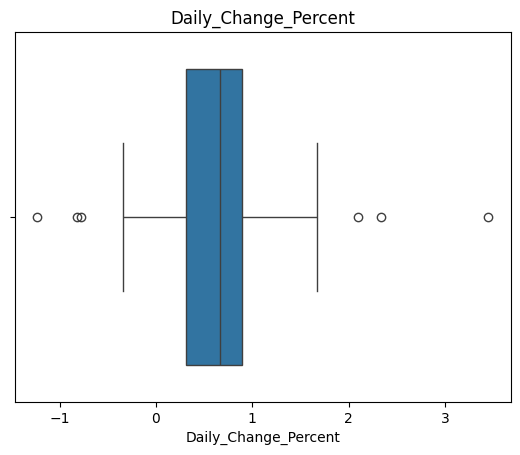

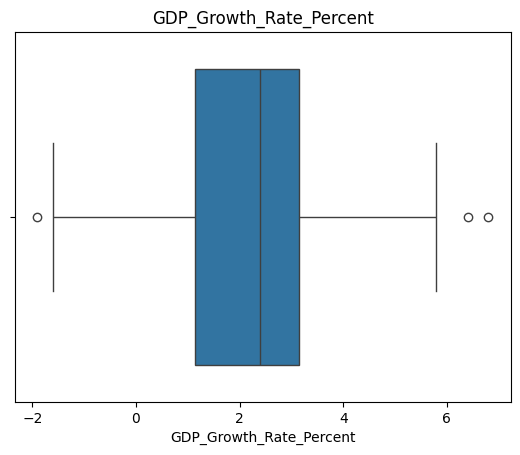

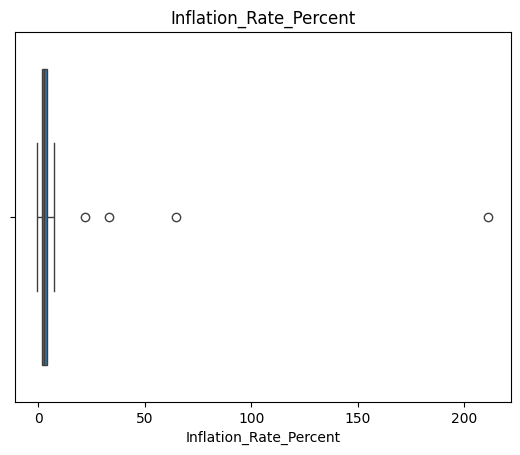

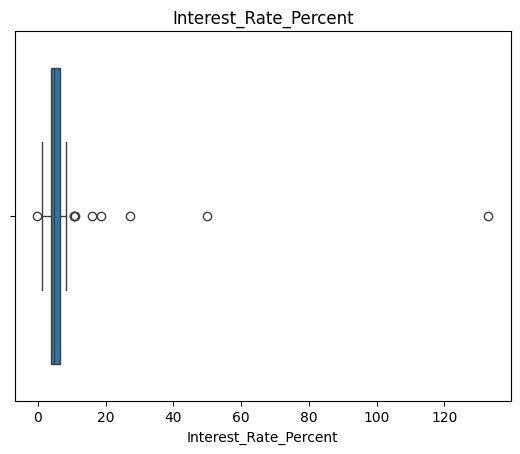

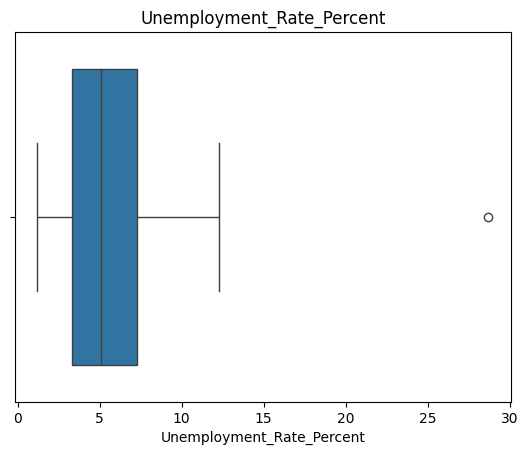

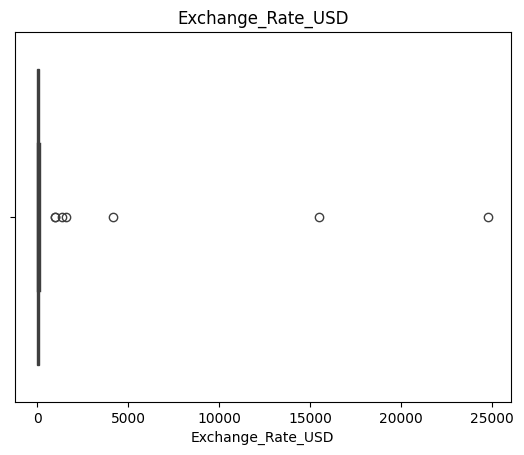

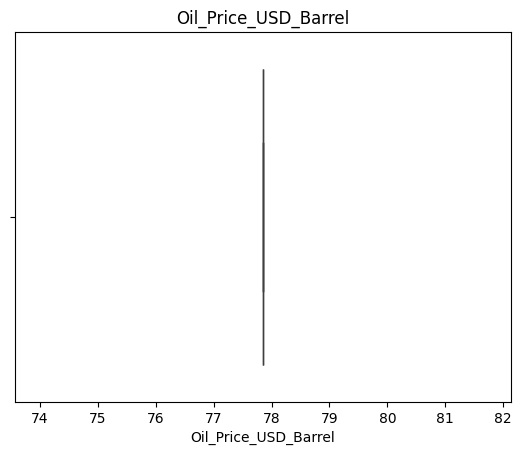

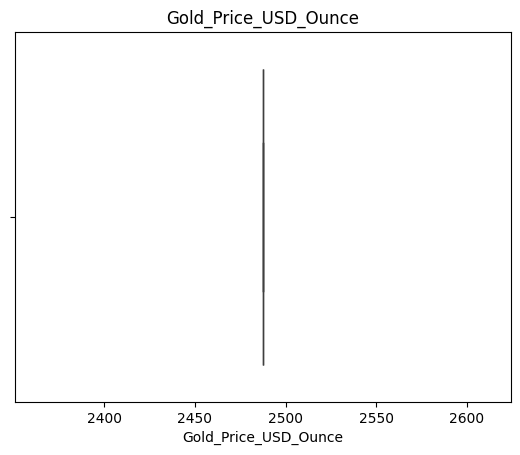

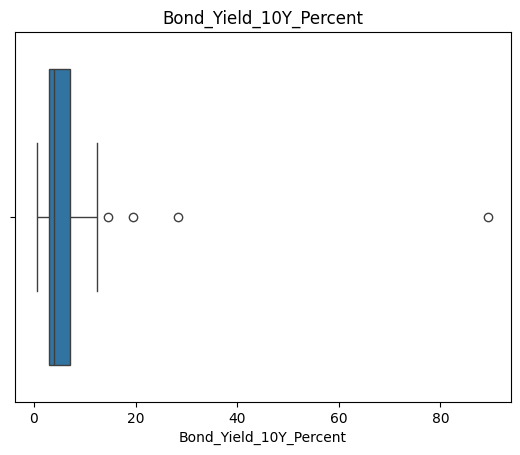

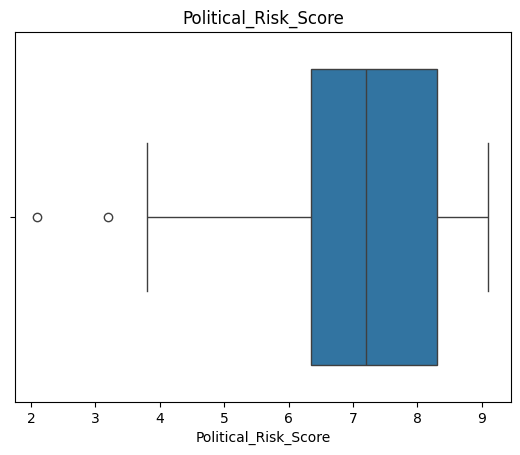

In [10]:
for col in data.select_dtypes(include='number').columns:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [18]:
numeric_data = data.select_dtypes(include='number')
# Separate features and target
predictor_cols = [
    'GDP_Growth_Rate_Percent',
    'Inflation_Rate_Percent',
    'Interest_Rate_Percent',
    'Unemployment_Rate_Percent',
    'Exchange_Rate_USD'
]

target_col = 'Daily_Change_Percent'

scaler = StandardScaler()
scaled_predictors = scaler.fit_transform(numeric_data[predictor_cols])
y = numeric_data[target_col]

# Create a DataFrame with scaled predictors
scaled_predictors_df = pd.DataFrame(scaled_predictors, columns=predictor_cols, index=numeric_data.index)

# Combine scaled predictors with the target
standardized_data = pd.concat([scaled_predictors_df, numeric_data[target_col]], axis=1)

standardized_data.head()

,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,Exchange_Rate_USD,Daily_Change_Percent
0,0.207859,-0.236279,-0.238300,-0.477935,-0.279659,0.34
1,1.504897,-0.297362,-0.349490,-0.150160,-0.278284,-0.82
2,-0.818963,-0.239187,-0.497744,-0.762006,-0.247654,1.24
3,-1.143223,-0.256640,-0.284629,-0.609045,-0.279677,0.67
4,-0.710877,-0.262457,-0.249882,-0.368676,-0.279707,-0.15


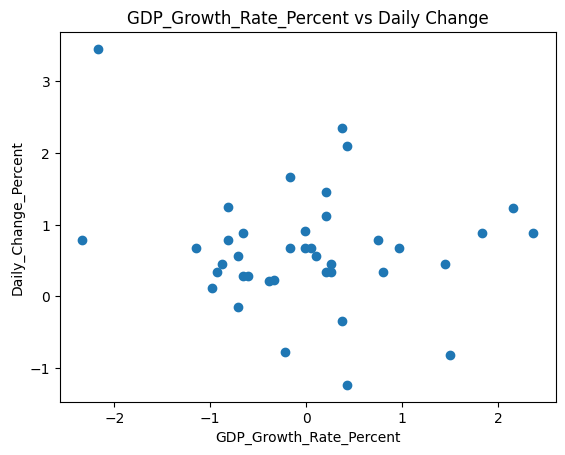

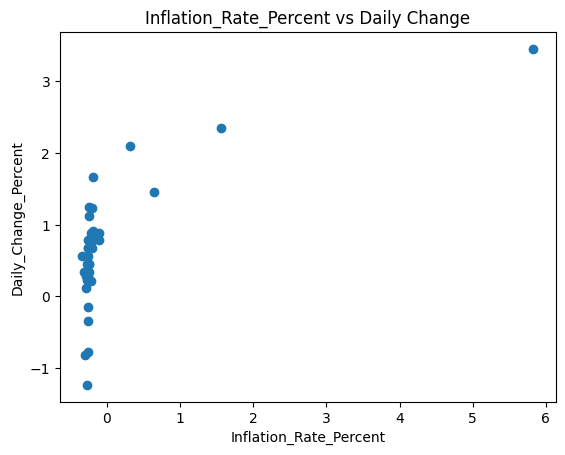

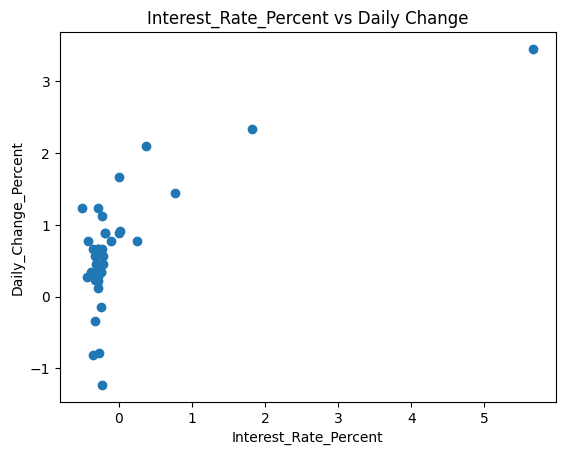

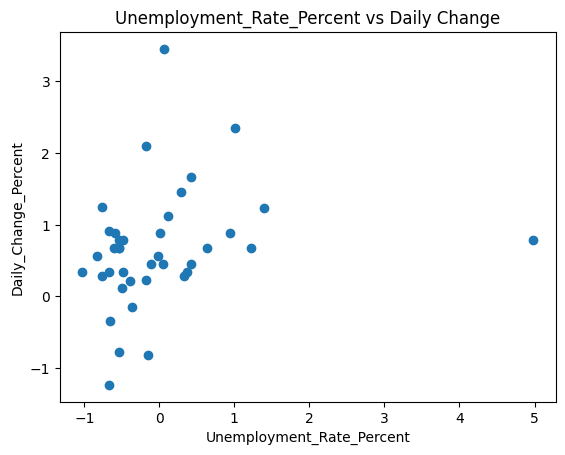

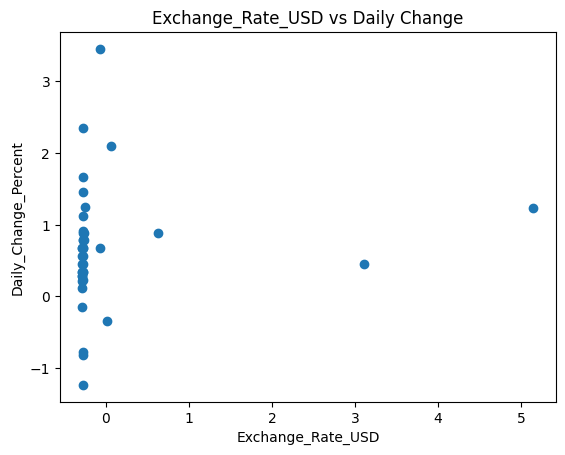

In [19]:
# Visualize distributions after scaling 

for col in scaled_predictors_df.columns:
    if col.startswith("Country_"):
        continue  # skip dummy variables
    
    plt.figure()
    plt.scatter(scaled_predictors_df[col], y)
    plt.xlabel(col)
    plt.ylabel("Daily_Change_Percent")
    plt.title(f"{col} vs Daily Change")
    plt.show()


In [ ]:
# Create mask: keep rows where ALL values <= 4
outlier_mask = (standardized_data[predictor_cols].abs() >= 3).any(axis=1)
standardized_data_clean = standardized_data[~outlier_mask]

In [22]:
print(f"\nRemoved {outlier_mask.sum()} outlier rows.")
print(f"Original data shape: {standardized_data.shape}")
print(f"Cleaned data shape: {standardized_data_clean.shape}")


Removed 4 outlier rows.
Original data shape: (39, 6)
Cleaned data shape: (35, 6)


#### Multicollinearity test for linear regression predictors

In [23]:
def calculate_vif(df, feature_list):
    X = df[feature_list].dropna()
    X['Intercept'] = 1

    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_data[vif_data['Feature'] != 'Intercept']

In [24]:
features = [
    'GDP_Growth_Rate_Percent',
    'Interest_Rate_Percent',
    'Unemployment_Rate_Percent',
    'Exchange_Rate_USD', 
]

print("\nMulticollinearity results:")
print(calculate_vif(numeric_data, features))


Multicollinearity results:
                     Feature       VIF
0    GDP_Growth_Rate_Percent  1.381694
1      Interest_Rate_Percent  1.140365
2  Unemployment_Rate_Percent  1.073527
3          Exchange_Rate_USD  1.289662


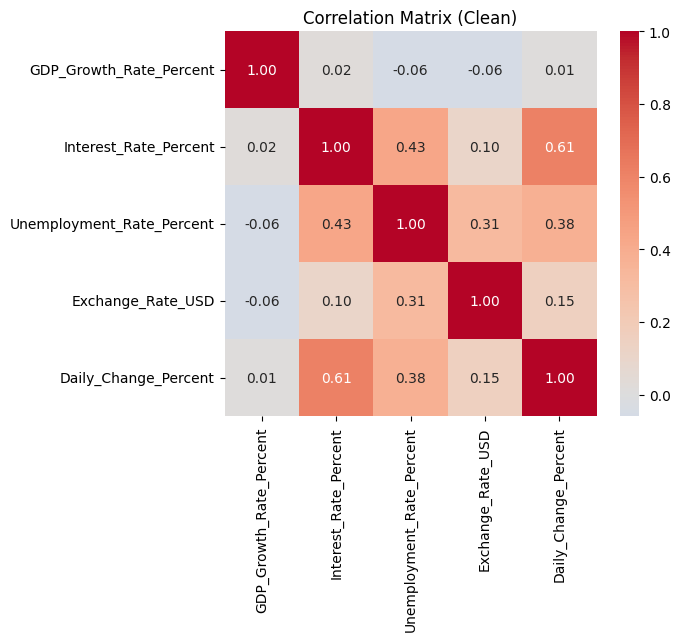

In [25]:
# Combine X and y for correlation
df_corr = standardized_data_clean.copy()
df_corr["Daily_Change_Percent"] = y

df_corr = pd.concat([df_corr[features], y], axis=1)

plt.figure(figsize=(6,5))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix (Clean)")
plt.show()

In [26]:
# Correlation with the target
corr_target = df_corr.corr()[target_col].sort_values(ascending = False)
print(corr_target)

Daily_Change_Percent         1.000000
Interest_Rate_Percent        0.608385
Unemployment_Rate_Percent    0.379393
Exchange_Rate_USD            0.152759
GDP_Growth_Rate_Percent      0.013827
Name: Daily_Change_Percent, dtype: float64


!! OBSERVATION FOR NEW MODEL
- Significant correlation between the target and the regressors
!! Multicollinearity check --> all good!


## OLS regression for cross-sectional data

### The first OLS

In [53]:
model_predictor_cols = [
    'GDP_Growth_Rate_Percent',
    'Interest_Rate_Percent',
    'Unemployment_Rate_Percent',
    'Exchange_Rate_USD',
]

target_col = 'Daily_Change_Percent'

X = standardized_data_clean[model_predictor_cols]
y = standardized_data_clean[target_col]

In [54]:
X = sm.add_constant(X)  # Add constant term for intercept

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Daily_Change_Percent   R-squared:                       0.389
Model:                              OLS   Adj. R-squared:                  0.308
Method:                   Least Squares   F-statistic:                     4.784
Date:                  Sat, 18 Apr 2026   Prob (F-statistic):            0.00418
Time:                          18:19:36   Log-Likelihood:                -29.350
No. Observations:                    35   AIC:                             68.70
Df Residuals:                        30   BIC:                             76.48
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.7818      0.175      4.460      0.000       0.424       1.140
GDP_Growth_Rate_Percent       0.0100      0.117      0.086      0.932      -0.229       0.249
Interest_Rate_Percent         0.9490      0.275      3.454      0.002       0.388       1.510
Unemployment_Rate_Percent     0.1579      0.212      0.744      0.463      -0.276       0.592
Exchange_Rate_USD             0.2471      0.648      0.381      0.706      -1.076       1.571
==============================================================================
Omnibus:                        6.589   Durbin-Watson:                   2.361
Prob(Omnibus):                  0.037   Jarque-Bera (JB):                5.192
Skew:                          -0.720   Prob(JB):                       0.0746
Kurtosis:                       4.220   Cond. No.                         6.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

!!! Intepretation
- The model explains roughly 39% of variation in daily change
- After penalizing for number of variables, the model still explain about 30% --> solid
- p-value = 0.00418 --> The model is statistically significant --> At least one predictor meaningfully explains the target
!!! Coeficients
- Interest Rate --> p-value = 0.001 (highly significant)
    - coef = 0.949 --> A 1 standard deviation increase in interest rate leads to an increase of roughly 0.95 (scaled units) in daily change index
- GDP Growth, Unemployment, Exchange Rate --> p-value > 0.05 -> not significant
- Intercept is statistically significant but not very meaningful here since data is scaled
!!! Model diagnostics
- Durbin-Watson = 2.36 --> residuals are independent
- Normality of residuals
    - Omnibus p = 0.037 → slight violation
    - JB p = 0.074 → borderline acceptable
    - Slight deviation from normality, but not severe
- Condition Number = 6.95 --> no multicollinearity

### The second OLS 

In [51]:
# Define the model
model_predictor_cols2 = [
    'Interest_Rate_Percent',
    'Unemployment_Rate_Percent',
    'Exchange_Rate_USD',
]

X2 = standardized_data_clean[model_predictor_cols2]
y2 = standardized_data_clean[target_col]

In [52]:
X2 = sm.add_constant(X2)  # Add constant term for intercept

model = sm.OLS(y2, X2).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Daily_Change_Percent   R-squared:                       0.389
Model:                              OLS   Adj. R-squared:                  0.330
Method:                   Least Squares   F-statistic:                     6.587
Date:                  Sat, 18 Apr 2026   Prob (F-statistic):            0.00142
Time:                          18:18:53   Log-Likelihood:                -29.354
No. Observations:                    35   AIC:                             66.71
Df Residuals:                        31   BIC:                             72.93
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.7811      0.172      4.534      0.000       0.430       1.132
Interest_Rate_Percent         0.9502      0.270      3.520      0.001       0.400       1.501
Unemployment_Rate_Percent     0.1568      0.209      0.752      0.458      -0.269       0.582
Exchange_Rate_USD             0.2448      0.637      0.384      0.703      -1.054       1.544
==============================================================================
Omnibus:                        6.323   Durbin-Watson:                   2.355
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                4.889
Skew:                          -0.705   Prob(JB):                       0.0868
Kurtosis:                       4.168   Cond. No.                         6.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

!!! Intepretation
- The model explains roughly 39% of variation in daily change 
- After penalizing for number of variables, the model still explain about 33% --> solid
- p-value = 0.00142 --> The model is statistically significant --> At least one predictor meaningfully explains the target
!!! Coeficients
- Interest Rate --> p-value = 0.001 (highly significant)
    - coef = 0.950 --> A 1 standard deviation increase in interest rate leads to an increase of roughly 0.95 (scaled units) in daily change index
- Unemployment, Exchange Rate --> p-value > 0.05 -> not significant
- Intercept is statistically significant but not very meaningful here since data is scaled
!!! Model diagnostics
- Durbin-Watson = 2.355 --> residuals are independent
- Normality of residuals
    - Omnibus p = 0.042 
    - Jarque-Bera p = 0.086 --> OK
    - Slight deviation from normality, but not severe
    - Skew = -0.705
- Condition Number = 6.94 --> no multicollinearity

### CONCLUSION

The first model, based on traditional macroeconomic variables (GDP growth, inflation, interest rates, and unemployment), showed limited explanatory power. Only the interest rate exhibited a meaningful relationship with the dependent variable

The second OLS model performs better. However, even in this specification, only a subset of variables remained statistically significant, while others did not contribute meaningfully to the model.